# Stage 1 Task 3 Collin Harris

# Imports

In [1]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

# Read Enrichment Data

In [2]:
housing = pd.read_csv("data/ACSDP1Y2022.DP04-Data.csv",low_memory=False)

# Read Covid Data

In [3]:
cases = pd.read_csv("data/covid_confirmed_usafacts.csv")
deaths = pd.read_csv("data/covid_deaths_usafacts.csv")
pop = pd.read_csv("data/covid_county_population_usafacts.csv")

# Filtering Covid data

In [4]:
cases = cases[cases['countyFIPS'] != 0]
deaths = deaths[deaths['countyFIPS'] != 0]
population = pop[pop['countyFIPS'] != 0]

# Merge Covid Data

In [5]:

covid = pd.merge(cases, deaths, on= ['countyFIPS','County Name', 'State','StateFIPS'], suffixes=('_cases', '_deaths'))
covid_data = pd.merge(covid,pop, on= ['countyFIPS'])

# Remove duplicate columns

In [6]:
columns_to_drop =["County Name_y", "State_y"]
covid_data.drop(columns=columns_to_drop, inplace=True)

# Display first 5 rows

In [7]:
covid_data.head()

,countyFIPS,County Name_x,State_x,StateFIPS,2020-01-22_cases,2020-01-23_cases,2020-01-24_cases,2020-01-25_cases,2020-01-26_cases,2020-01-27_cases,...,2023-07-15_deaths,2023-07-16_deaths,2023-07-17_deaths,2023-07-18_deaths,2023-07-19_deaths,2023-07-20_deaths,2023-07-21_deaths,2023-07-22_deaths,2023-07-23_deaths,population
0,1001,Autauga County,AL,1,0,0,0,0,0,0,...,235,235,235,235,235,235,235,235,235,55869
1,1003,Baldwin County,AL,1,0,0,0,0,0,0,...,731,731,731,731,731,731,731,731,731,223234
2,1005,Barbour County,AL,1,0,0,0,0,0,0,...,104,104,104,104,104,104,104,104,104,24686
3,1007,Bibb County,AL,1,0,0,0,0,0,0,...,111,111,111,111,111,111,111,111,111,22394
4,1009,Blount County,AL,1,0,0,0,0,0,0,...,261,261,261,261,261,261,261,261,261,57826


In [8]:
# rename the column names for merge later
column_rename = {
    'County Name_x': 'County Name',
    'State_x': 'State'
}

# Rename the columns with suffixes
covid_data.rename(columns=column_rename, inplace=True)

In [20]:
wa_data = covid_data.loc[covid_data['State'] == 'WA']

In [21]:
wa_data.head()

,countyFIPS,County Name,State,StateFIPS,2020-01-22_cases,2020-01-23_cases,2020-01-24_cases,2020-01-25_cases,2020-01-26_cases,2020-01-27_cases,...,2023-07-15_deaths,2023-07-16_deaths,2023-07-17_deaths,2023-07-18_deaths,2023-07-19_deaths,2023-07-20_deaths,2023-07-21_deaths,2023-07-22_deaths,2023-07-23_deaths,population
2953,53001,Adams County,WA,53,0,0,0,0,0,0,...,51,51,51,51,51,51,51,51,51,19983
2954,53003,Asotin County,WA,53,0,0,0,0,0,0,...,84,84,84,84,84,84,84,84,84,22582
2955,53005,Benton County,WA,53,0,0,0,0,0,0,...,547,547,547,547,547,548,548,548,548,204390
2956,53007,Chelan County,WA,53,0,0,0,0,0,0,...,184,184,184,184,184,184,184,184,184,77200
2957,53009,Clallam County,WA,53,0,0,0,0,0,0,...,213,213,213,213,213,213,213,213,213,77331


In [26]:
past_week_cases = wa_data.filter(regex='_cases', axis=1).iloc[:,-7:]
past_week_cases.sum()

2023-07-17_cases    1965374
2023-07-18_cases    1965374
2023-07-19_cases    1965374
2023-07-20_cases    1966664
2023-07-21_cases    1966664
2023-07-22_cases    1966664
2023-07-23_cases    1966664
dtype: int64

In [27]:
past_week_deaths = wa_data.filter(regex='_deaths', axis=1).iloc[:,-7:]
past_week_deaths.sum()

2023-07-17_deaths    15941
2023-07-18_deaths    15941
2023-07-19_deaths    15941
2023-07-20_deaths    15956
2023-07-21_deaths    15956
2023-07-22_deaths    15956
2023-07-23_deaths    15956
dtype: int64

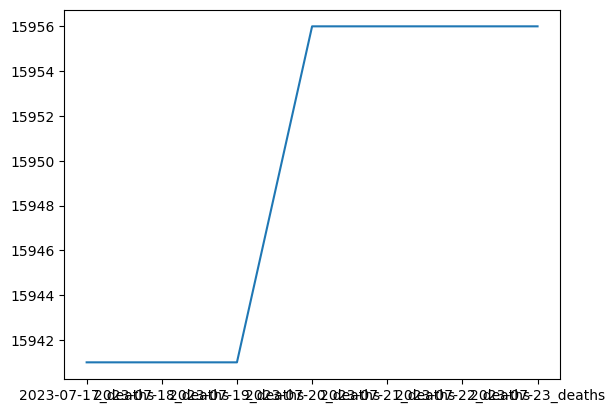

In [28]:
time_plot_deaths = plt.plot(past_week_deaths.sum())

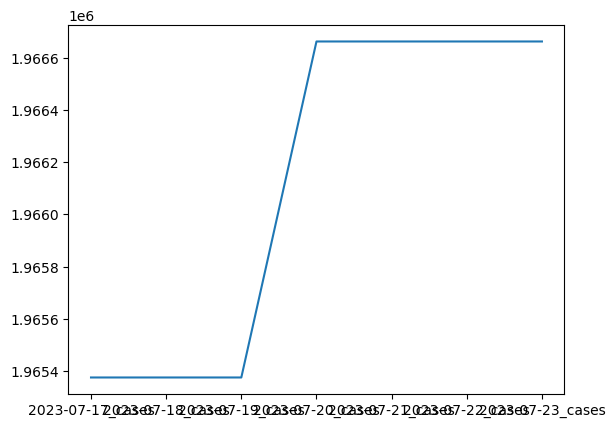

In [29]:
time_plot_cases = plt.plot(past_week_cases.sum())

##### Interpretation
In both deaths and cases the data suggest there was an increase on the 19th of July 
deaths increased by 15 and total cases increased by 1,290; this is likely due to the method
data is collected in as to why such a sudden increase.

# Display first 5 rows of unmodified housing data

In [9]:
housing.head()

,GEO_ID,NAME,DP04_0001E,DP04_0001M,DP04_0001MA,DP04_0001EA,DP04_0002E,DP04_0002EA,DP04_0002M,DP04_0002MA,...,DP04_0141PMA,DP04_0142PE,DP04_0142PEA,DP04_0142PM,DP04_0142PMA,DP04_0143PE,DP04_0143PEA,DP04_0143PM,DP04_0143PMA,Unnamed: 1146
0,Geography,Geographic Area Name,Estimate!!HOUSING OCCUPANCY!!Total housing units,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,Annotation of Margin of Error!!HOUSING OCCUPAN...,Annotation of Estimate!!HOUSING OCCUPANCY!!Tot...,Estimate!!HOUSING OCCUPANCY!!Total housing uni...,Annotation of Estimate!!HOUSING OCCUPANCY!!Tot...,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,Annotation of Margin of Error!!HOUSING OCCUPAN...,...,Annotation of Percent Margin of Error!!GROSS R...,Percent!!GROSS RENT AS A PERCENTAGE OF HOUSEHO...,Annotation of Percent!!GROSS RENT AS A PERCENT...,Percent Margin of Error!!GROSS RENT AS A PERCE...,Annotation of Percent Margin of Error!!GROSS R...,Percent!!GROSS RENT AS A PERCENTAGE OF HOUSEHO...,Annotation of Percent!!GROSS RENT AS A PERCENT...,Percent Margin of Error!!GROSS RENT AS A PERCE...,Annotation of Percent Margin of Error!!GROSS R...,NaN
1,0500000US01003,"Baldwin County, Alabama",132299,185,NaN,NaN,98854,NaN,3781,NaN,...,NaN,46.3,NaN,9.2,NaN,(X),(X),(X),(X),NaN
2,0500000US01015,"Calhoun County, Alabama",53408,87,NaN,NaN,45701,NaN,1562,NaN,...,NaN,34.9,NaN,8.8,NaN,(X),(X),(X),(X),NaN
3,0500000US01043,"Cullman County, Alabama",39893,40,NaN,NaN,35966,NaN,1274,NaN,...,NaN,39.7,NaN,14.3,NaN,(X),(X),(X),(X),NaN
4,0500000US01049,"DeKalb County, Alabama",31022,39,NaN,NaN,26459,NaN,1114,NaN,...,NaN,32.4,NaN,12.6,NaN,(X),(X),(X),(X),NaN


# Data types of Housing Dataset

In [10]:
housing.dtypes

GEO_ID            object
NAME              object
DP04_0001E        object
DP04_0001M        object
DP04_0001MA       object
                  ...   
DP04_0143PE       object
DP04_0143PEA      object
DP04_0143PM       object
DP04_0143PMA      object
Unnamed: 1146    float64
Length: 1147, dtype: object

# Removing Annotation Columns

In [11]:
housing = housing.loc[:, ~housing.columns.str.endswith('A')]
housing = housing[housing.columns[~housing.columns.str.endswith('A')]]

In [12]:
#also replacing name for later merge
housing.rename(columns={'NAME': 'County Name'}, inplace=True)

# Preparing for merge
    the GEO_ID column has the same id's shown in the covid data
    all we must do is remove the prefixes and fix the typing

# Removing prefixes 

In [13]:
housing['GEO_ID'] = housing['GEO_ID'].str.replace("0500000US0",'')

# Renaming GEO_ID for merge

In [14]:
housing = housing.rename(columns={"GEO_ID":"countyFIPS"})
housing.head()

,countyFIPS,County Name,DP04_0001E,DP04_0001M,DP04_0002E,DP04_0002M,DP04_0003E,DP04_0003M,DP04_0004E,DP04_0004M,...,DP04_0139PM,DP04_0140PE,DP04_0140PM,DP04_0141PE,DP04_0141PM,DP04_0142PE,DP04_0142PM,DP04_0143PE,DP04_0143PM,Unnamed: 1146
0,Geography,Geographic Area Name,Estimate!!HOUSING OCCUPANCY!!Total housing units,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,Estimate!!HOUSING OCCUPANCY!!Total housing uni...,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,Estimate!!HOUSING OCCUPANCY!!Total housing uni...,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,Estimate!!HOUSING OCCUPANCY!!Total housing uni...,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,...,Percent Margin of Error!!GROSS RENT AS A PERCE...,Percent!!GROSS RENT AS A PERCENTAGE OF HOUSEHO...,Percent Margin of Error!!GROSS RENT AS A PERCE...,Percent!!GROSS RENT AS A PERCENTAGE OF HOUSEHO...,Percent Margin of Error!!GROSS RENT AS A PERCE...,Percent!!GROSS RENT AS A PERCENTAGE OF HOUSEHO...,Percent Margin of Error!!GROSS RENT AS A PERCE...,Percent!!GROSS RENT AS A PERCENTAGE OF HOUSEHO...,Percent Margin of Error!!GROSS RENT AS A PERCE...,NaN
1,1003,"Baldwin County, Alabama",132299,185,98854,3781,33445,3873,0.1,0.1,...,6.3,10.7,4.8,4.9,2.7,46.3,9.2,(X),(X),NaN
2,1015,"Calhoun County, Alabama",53408,87,45701,1562,7707,1573,1.0,1.1,...,4.8,10.5,5.6,7.7,4.1,34.9,8.8,(X),(X),NaN
3,1043,"Cullman County, Alabama",39893,40,35966,1274,3927,1285,0.9,1.4,...,6.0,17.1,9.2,5.4,4.3,39.7,14.3,(X),(X),NaN
4,1049,"DeKalb County, Alabama",31022,39,26459,1114,4563,1114,0.7,0.8,...,9.4,13.6,9.0,3.9,3.4,32.4,12.6,(X),(X),NaN


# Type matching
    Because the GEO_ID was an object type and countyFIPS was an int64 type 
    we must cast to match both types to a string value

In [15]:
final_merged_data=housing.astype(str).merge(covid_data.astype(str), 'left')

# First 5 rows of our new merged data

In [16]:
final_merged_data.head()

,countyFIPS,County Name,DP04_0001E,DP04_0001M,DP04_0002E,DP04_0002M,DP04_0003E,DP04_0003M,DP04_0004E,DP04_0004M,...,2023-07-15_deaths,2023-07-16_deaths,2023-07-17_deaths,2023-07-18_deaths,2023-07-19_deaths,2023-07-20_deaths,2023-07-21_deaths,2023-07-22_deaths,2023-07-23_deaths,population
0,Geography,Geographic Area Name,Estimate!!HOUSING OCCUPANCY!!Total housing units,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,Estimate!!HOUSING OCCUPANCY!!Total housing uni...,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,Estimate!!HOUSING OCCUPANCY!!Total housing uni...,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,Estimate!!HOUSING OCCUPANCY!!Total housing uni...,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1003,"Baldwin County, Alabama",132299,185,98854,3781,33445,3873,0.1,0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1015,"Calhoun County, Alabama",53408,87,45701,1562,7707,1573,1.0,1.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1043,"Cullman County, Alabama",39893,40,35966,1274,3927,1285,0.9,1.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1049,"DeKalb County, Alabama",31022,39,26459,1114,4563,1114,0.7,0.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
